## Adaptive Parareal

Before going to a battery model, we can consider the modified non-homogeneous Dahlquist problem :

$$
\frac{du}{dt} = \lambda(t) u + \sin(\alpha t), \quad u(t_0) = u_0, \quad t \in [t_0, t_1],
$$

where $\lambda(t) = 1j(1+\epsilon(n))$ and $\epsilon(n)$ a small variation that varies after one period (i.e when $\Im(u)$ reaches 0 for the second time).
Since the period is $T=2\pi/\|\lambda(t)\|$, this will emulate a pseudo-periodic problem and the idea is to implement the Parareal algorithm such that is works on this.

> First, we can consider a step function for $\epsilon(n) = 0.01 n$ where $n$ is the index of the time-windows.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

root = Path.cwd().resolve()
while root != root.parent and not (root / "scripts" / "notebooks").exists():
    root = root.parent
root = root / "scripts" / "notebooks"
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
    
from DahlquistProblem.tmp.numericalSolDahlquist import *
from Solver.AdaptiveParareal import PararealModified
from Solver.BackwardEuler import BackwardEuler
from Solver.BackwardEulerEvent import BackwardEulerEvent
from Solver.Newton import Newton
from ModifiedProblem.modified_dahlquist import exact_local_solution, exact_global_solution, f_ODE, check_event
from Solver.solve_event_sequence import solve_event_sequence

# Dahlquist test problem parameters
alpha = 6.001   # to avoid resonance regime
u0 = 1+0j
t0 = 0
pStart = 1
N = 10
lam = lambda n: 1j*(1+0.01*n)

print(f"alpha = {alpha}, u0 = {u0}, t0 = {t0}, pStart = {pStart}, N = {N}, lam(n) = 1j*(1+0.01*n)")

alpha = 6.001, u0 = (1+0j), t0 = 0, pStart = 1, N = 10, lam(n) = 1j*(1+0.01*n)


Under the condition that $\lambda^2 + \alpha^2 \neq 0$ (resonance regime), then the analytical solution of this ordinary differential equation in the pseudo-period $n$ is :

$$
u_{th}(t) = C e^{\lambda (n) t} - \frac{\alpha \cos(\alpha t) + \lambda (n)\sin(\alpha t)}{\alpha^2 + (\lambda(n))^2},
$$
where the constant $C$ depends on the initial solution $u_0$:
$$
C = e^{-\lambda(n) t_0}\left[u_0 + \frac{\alpha \cos(\alpha t_0) + \lambda (n)\sin(\alpha t_0)}{\alpha^2 + (\lambda(n))^2}\right]
$$

Considering the parameter values $\lambda=1j$ and $\alpha=6.001$ and intial conditions $u_0 = 1$, we can plot the solution for $N$ pseudo-periods in the complex plane like this :

In [2]:
# analytical solution
dt = 0.001
tEx, uEx, tpEx, upEx = exact_global_solution(
    u_start = u0,
    t_start = t0,
    alpha = alpha,
    lam = lam,
    Period_start = pStart,
    Period_end = pStart + N - 1,
    dt = dt
)

Plot of the analytical solution:

Dahlquist problem solved for:
N = 10 periods
dt = 0.001


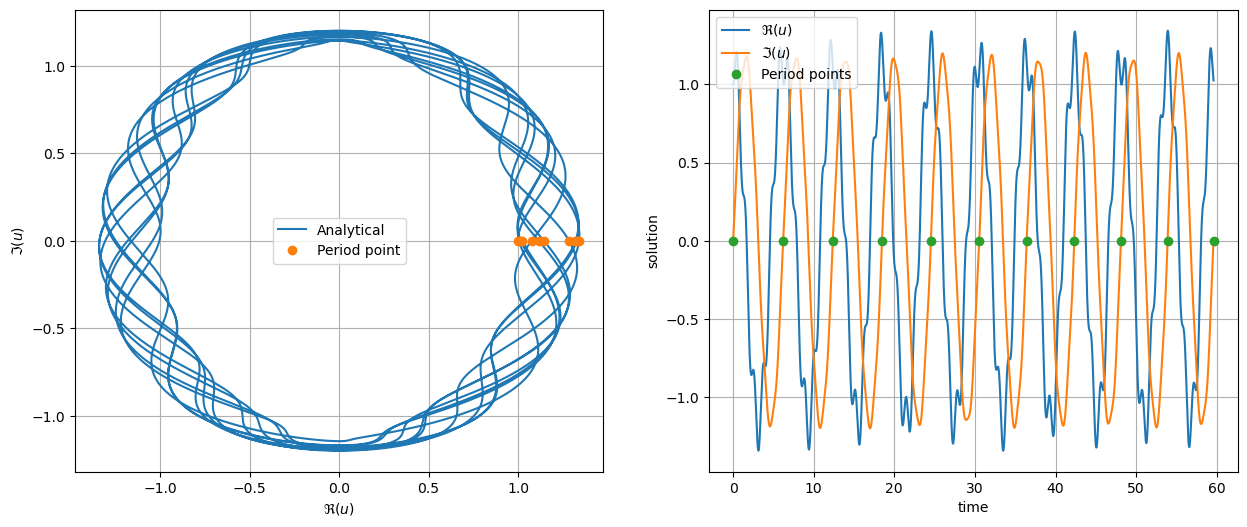

In [3]:
print(f"Dahlquist problem solved for:\nN = {N} periods\ndt = {dt}")

plt.figure(figsize=(15, 6))
# plot Re vs Im parts of the analytical solution
plt.subplot(1, 2, 1)
plt.plot(uEx.real, uEx.imag, label="Analytical")
plt.plot(upEx.real, upEx.imag, "o", label="Period point")
plt.legend(), plt.xlabel(r"$\Re(u)$"), plt.ylabel(r"$\Im(u)$"), plt.grid();

# plot Re/Im-solution parts vs time
plt.subplot(1, 2, 2)
plt.plot(tEx, uEx.real, label=r"$\Re(u)$")
plt.plot(tEx, uEx.imag, label=r"$\Im(u)$")
plt.plot(tpEx, np.array(upEx).imag, 'o', label="Period points")
plt.legend(loc="upper left"), plt.xlabel("time"), plt.ylabel("solution"), plt.grid();

For the time discretization, we use the Backward Euler method applied to the non-homogeneous Dahlquist equation
$$
\frac{du}{dt}=\lambda(t)u+\sin(\alpha t),
$$
where $\lambda(t)=i(1+\epsilon(n))$ is constant during one pseudo-period and is updated only from one cycle to the next. On a time step $t_i \to t_{i+1}$, the BE-Solution is given as 
$$
u_{i+1}
=\frac{u_i+\Delta t\sin(\alpha t_{i+1})}
{1-\Delta t\lambda_n}.
$$

The solver advances the solution with this formula until the imaginary part of $u$ crosses zero for the second time: `occurence += u_1.imag*u_2.image >=0`. This crossing is used to identify the end of the current pseudo-period. Since the crossing usually does not occur exactly at a time-grid point, a linear interpolation between the two surrounding time steps is used to approximate both the pseudo-periodic time and the corresponding solution value. This interpolated value is then taken as the initial condition for the next pseudo-period, where a new value of $\lambda_n$ may be used. In this way, the solver constructs a sequence of local solutions over successive pseudo-periods.

Lets compute the numerical solution and compare it with the analytical one:


In [4]:
# numerical solution
dtNum = 0.001
def reset_parameters(t, u, event_count):
        f = lambda t, y: f_ODE(t, y, alpha, lam(event_count+pStart))
        df = lambda t, y: lam(event_count+pStart)
        return f, df

event_func = lambda t0, u0, t, u, event_count: check_event(
    t0,
    u0,
    t,
    u,
    alpha,
    lam(event_count+pStart),) 


tNum, uNum, tpNum, upNum, pPeriods  = solve_event_sequence(
        t0,
        u0,
        dt=dtNum,
        reset_parameters=reset_parameters,
        Event_Solver = BackwardEulerEvent,
        event_func=event_func,
        num_events=N,
    )
# plot Re vs Im parts of the 
# analytical and numerical solutions 
uNum_all = np.concatenate(uNum)
tNum_all = np.concatenate(tNum)
print(f"Dahlquist problem solved numerically for:\nN = {N} periods\ndt = {dtNum}")

Dahlquist problem solved numerically for:
N = 10 periods
dt = 0.001


Plot for the numerical solution:

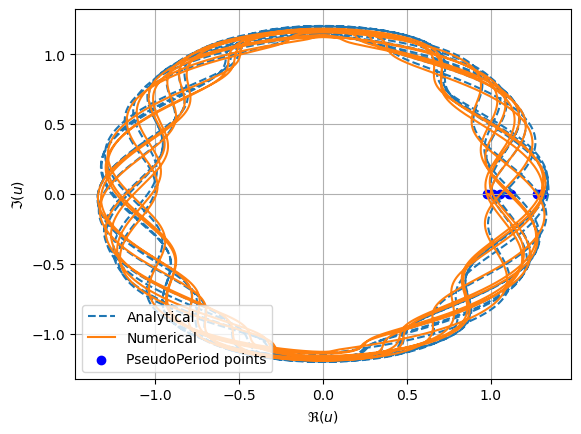

In [5]:
plt.figure()
plt.plot(uEx.real, uEx.imag, "--", label="Analytical")
plt.plot(uNum_all.real, uNum_all.imag, label="Numerical")
plt.scatter([upNum[i].real for i in range(pPeriods)], [upNum[i].imag for i in range(pPeriods)], color='blue', label='PseudoPeriod points')
plt.legend(loc="lower left"), plt.xlabel(r"$\Re(u)$"), plt.ylabel(r"$\Im(u)$"), plt.grid();

I wanted to know which solver is faster so I compared them:

In [6]:
import time
# Event sequence solver
dt = 1e-3
event_func = lambda t0, u0, t, u, event_count: check_event(
            t0,
            u0,
            t,
            u,
            alpha,
            lam(event_count+pStart),) 
time_sequential_start = time.time()
tp_seq,up_seq = solve_event_sequence(
            t0,
            u0,
            dt=dt,
            reset_parameters=reset_parameters,
            Event_Solver = BackwardEulerEvent,
            event_func=event_func,
            num_events=N,        )[2:-1]
time_sequential_end = time.time()
print(f"Sequential event solver time: {time_sequential_end - time_sequential_start:.6f} seconds")

# Solve with Backward Euler & Newton method
tpBEN = np.zeros(N + 1, dtype=float)
upBEN = np.zeros(N + 1, dtype = complex)
tpBEN[0] = t0
upBEN[0] = u0.copy() if isinstance(u0, np.ndarray) else u0
time_BE_loop_start = time.time()
for numevent in range(N):
    f,df = reset_parameters(tpBEN[numevent], upBEN[numevent], numevent)
    event_func = lambda t, u: check_event(tpBEN[numevent], upBEN[numevent], t, u, alpha, lam(numevent+1))
    tpnum, upnum = BackwardEulerEvent(
        f,
        df,
        tpBEN[numevent],
        upBEN[numevent],
        dt=dt,
        event_func=event_func,
        )[2:]
    tpBEN[numevent + 1] = tpnum
    upBEN[numevent + 1] = upnum
time_BE_loop_end = time.time()
print(f"Backward Euler & Newton method: {time_BE_loop_end - time_BE_loop_start:.6f} seconds")

#Solver Backward Euler direct solver
time_direct_start = time.time()
u_start = u0.copy() if isinstance(u0, np.ndarray) else u0
t_start = t0
tp_BE = np.zeros(N + 1, dtype=float)
up_BE = np.zeros(N + 1, dtype = complex)
tp_BE[0] = t_start
up_BE[0] = u_start
for numevent in range(N):
    f,df = reset_parameters(tp_BE[numevent], up_BE[numevent], numevent)
    event_func = lambda t, u: check_event(tp_BE[numevent], up_BE[numevent], t, u, alpha, lam(numevent+1))
    tpnum, upnum = directSolverDahlquistEvent(f,df,y0=up_BE[numevent], t0=tp_BE[numevent], dt=dt, alpha=alpha, lam=lam(numevent+1),event_func=event_func)[2:]
    tp_BE[numevent + 1] = tpnum
    up_BE[numevent + 1] = upnum
time_direct_end = time.time()
print(f"Backward Euler direct solver: {time_direct_end - time_direct_start:.6f} seconds")

Sequential event solver time: 5.373013 seconds
Backward Euler & Newton method: 5.213063 seconds
Backward Euler direct solver: 0.589087 seconds


We compare the Backward Euler approximation with the analytical solution. In this problem, the decomposition of the time domain is not known in advance, because the end of each pseudo-period is determined dynamically. Therefore, the solver does not only approximate the solution $u(t)$, but also the pseudo-periodic times $T_n$. For this reason, we measure two errors: one for the detected pseudo-period times and one for the solution values at the end of each pseudo-period.

Using the analytical solution as reference, we define the errors in the (L^\infty)-norm as
$$
e_T
=\|tP_{ex} -tP_{num}\|_\infty,
$$
and
$$
e_u
=\|uP_{ex} -uP_{num}\|_\infty,
$$
where $tP$ denotes the end time of the $n$-th pseudo-periods and $uP=u(tP)$ is the corresponding solution value.


In [7]:
# compute L_inf error between solutions
dtVals  =  1./(10**np.arange(1,6))

error_TP = np.zeros_like(dtVals)
error_UP = np.zeros_like(dtVals)

TP_num = np.zeros((len(dtVals),N + 1), dtype=float)
UP_num = np.zeros((len(dtVals),N + 1), dtype = complex)

TP_th = np.zeros((len(dtVals),N + 1), dtype=float)
UP_th = np.zeros((len(dtVals),N + 1), dtype = complex)

> I tried to solve without using the sequential solver, bacause I thought the loop over N with Backward-EulerEvent function would work faster....

Then I tried the direct solver and it is the fastest...

In [ ]:
for i, dt in enumerate(dtVals):
    tTh, uTh,tpTh,upTh = exact_global_solution(
            u_start = u0,
            t_start = t0,
            alpha = alpha,
            lam = lam,
            Period_start = pStart,
            Period_end = pStart + N - 1,
            dt = dt
            )
    TP_th[i,:] = tpTh
    UP_th[i,:] = upTh
    t_start = t0
    u_start = u0.copy() if isinstance(u0, np.ndarray) else u0
    TP_num[i,0] = t0
    UP_num[i,0] = u0.copy() if isinstance(u0, np.ndarray) else u0
    for numevent in range(N):
        f,df = reset_parameters(t_start, u_start, numevent)

        tpnum, upnum = directSolverDahlquistEvent(f,df,y0=UP_num[i,numevent], t0=TP_num[i,numevent], dt=dt, alpha=alpha, lam=lam(numevent+1),event_func=event_func)[2:]
        TP_num[i,numevent+1] = tpnum
        UP_num[i,numevent+1] = upnum.copy() if isinstance(upnum, np.ndarray) else upnum

    error_UP[i] = np.linalg.norm(UP_num[i,:]-UP_th[i,:], ord=np.inf)
    error_TP[i] = np.linalg.norm(TP_num[i,:]-TP_th[i,:], ord=np.inf)  


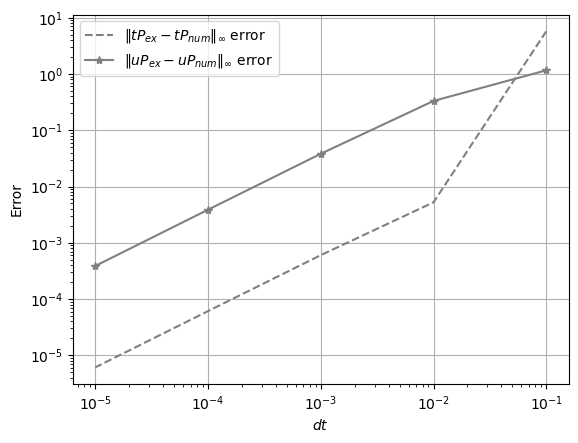

In [9]:
plt.figure()
plt.loglog(dtVals, error_TP, "--", c="gray", label=r"$\|tP_{ex} -tP_{num}\|_\infty$ error")
plt.loglog(dtVals, error_UP, "-*", c="gray", label=r"$\|uP_{ex} -uP_{num}\|_\infty$ error")
plt.xlabel("$dt$"), plt.ylabel("Error"), plt.grid();
plt.legend();

### Shooting parameters
We consider the initial value problem
$$
\frac{d}{dt}\mathbf{u}(t)=\mathbf{f}(t,\mathbf{u}(t)), \qquad t\in(0,T],
$$
with
$$
\mathbf{u}(t_0)=\mathbf{u}_0,
\qquad
\mathbf{u}:\mathbb R \to \mathbb R^n.
$$
We assume that the solution is *pseudoperiodic*. We divide the time domain into local pseudoperiods,
$$
(0,T]=(T_0,T_1]\cup(T_1,T_2]\cup\cdots\cup(T_{N-1},T_N],
$$
where
$$
T_0=t_0,
\qquad
T_N=T.
$$
The times $T_1,\dots,T_{N-1}$ are not known in advance. At each pseudoperiod point, we define the shooting value $\mathbf{U}_k=\mathbf{u}(T_k).$
The shooting unknown is therefore the pair
$$
\mathbf{Z}_k=
\begin{pmatrix}
\mathbf{U}_k\\
T_k
\end{pmatrix}.
$$
On each local interval $(T_k,T_{k+1}]$, the local solution $\mathbf{u}_k$ is defined by
$$
\frac{d}{dt}\mathbf{u}_k(t)=\mathbf{f}(t,\mathbf{u}_k(t)),
\qquad
\mathbf{u}_k(T_k)=\mathbf{U}_k.
$$
and it depends on time and initial time and value, like $\mathbf{u}_k(t)=\mathbf{u}_k(t;(\mathbf{U}_k,T_{k}))$. Since the next endpoint $T_{k+1}$ is not known beforehand, the local solver is viewed as a map from one solution-time pair to the next:
$$
\boldsymbol{\Phi}_k(\mathbf{U}_k,T_k)=(\mathbf{U}_{k+1},T_{k+1}).
$$
The value $U_{k+1}$​ is the local solution evaluated at the newly determined endpoint $T_{k+1}$​, namely
$$u_k(T_{k+1};(\mathbf{U}_k,T_{k}))=\mathbf{U}_{k+1}.$$
$$\boldsymbol{\Phi}_k(\mathbf{Z}_k)=(\boldsymbol{\Phi}_k^1(\mathbf{Z}_k),\Phi_k^2(\mathbf{Z}_k) )= (\mathbf{u}_{k}(\Phi_k^2(\mathbf{Z}_k);\mathbf{Z}_k),\Phi_k^2(\mathbf{Z}_k))=\mathbf{Z}_{k+1}.$$
The nonlinear matching problem is formulated in terms of the sequence
$$\mathbf{Z}_0,\mathbf{Z}_1,\dots,\mathbf{Z}_N.$$
Since the initial value is prescribed, we have
$$
\mathbf{Z}_0=
\mathbf{Z}^0
=
\begin{pmatrix}
\mathbf{u}_0\\
t_0
\end{pmatrix}.
$$
This gives the nonlinear shooting system
$$
\mathbf{F}(\mathbf{Z})=
\begin{pmatrix}
\mathbf{Z}_0-\mathbf{Z}^0\\
\mathbf{Z}_1-\boldsymbol{\Phi}_0(\mathbf{Z}_0)\\
\mathbf{Z}_2-\boldsymbol{\Phi}_1(\mathbf{Z}_1)\\
\vdots\\
\mathbf{Z}_N-\boldsymbol{\Phi}_{N-1}(\mathbf{Z}_{N-1})
\end{pmatrix}
=
\mathbf{0}.
$$
Applying Newton's method to this nonlinear system gives
$$
\mathbf{F}'(\mathbf{Z}^{j})\Delta \mathbf{Z}^{j}
=
-\mathbf{F}(\mathbf{Z}^{j}),
$$
followed by the update
$$
\mathbf{Z}^{j+1}
=
\mathbf{Z}^{j}
+
\Delta \mathbf{Z}^{j}.
$$
The Jacobian has the block structure
$$
\mathbf{F}'(\mathbf{Z}^{j})
=
\begin{pmatrix}
I & 0 & 0 & \cdots & 0\\
-\mathbf{J}_0^{j} & I & 0 & \cdots & 0\\
0 & -\mathbf{J}_1^{j} & I & \cdots & 0\\
0 & 0 & -\mathbf{J}_2^{j} & \ddots & 0\\
\vdots & \vdots & \vdots & \ddots & I
\end{pmatrix},
$$
where
$$
\mathbf{J}_k^{j}
=D\boldsymbol{\Phi}_k(\mathbf{Z}_k^{j})=
\left.
\frac{\partial(\boldsymbol{\Phi}_k(\mathbf{U}_{k},T_{k}))}
{\partial(\mathbf{U}_k,T_k)}
\right|_{\mathbf{Z}_k=\mathbf{Z}_k^{j}}.
$$
Explicitly,
$$
\mathbf{J}_k^{j}
=
\begin{pmatrix}
\dfrac{\partial \boldsymbol{\Phi}_k^1(\mathbf{U}_k,T_k)}{\partial \mathbf{U}_k}
&
\dfrac{\partial \boldsymbol{\Phi}_k^1(\mathbf{U}_k,T_k)}{\partial T_k}
\\[1.2em]
\dfrac{\partial \Phi_k^2(\mathbf{U}_k,T_k)}{\partial \mathbf{U}_k}
&
\dfrac{\partial \Phi_k^2(\mathbf{U}_k,T_k)}{\partial T_k}
\end{pmatrix}_{\mathbf{Z}_k=\mathbf{Z}_k^{j}}.
$$

>$$\dfrac{\partial \boldsymbol{\Phi}_k^1(\mathbf{U}_k,T_k)}{\partial \mathbf{U}_k}=\left.\dfrac{\partial \mathbf{u}_{k}(t;T_k,\mathbf{U}_k)}{\partial \mathbf{U}_k}\right|_{t=T_{k+1}}+\mathbf{f}(T_{k+1},\mathbf{U}_{k+1})\dfrac{\partial \Phi_k^2}{\partial \mathbf{U}_k}$$

>$$\dfrac{\partial \boldsymbol{\Phi}_k^1(\mathbf{U}_k,T_k)}{\partial T_k}=\mathbf{f}(T_{k+1},\mathbf{U}_{k+1})\dfrac{\partial \Phi_k^2}{\partial T_k}-\left.\dfrac{\partial \mathbf{u}_{k}(t;T_k,\mathbf{U}_k)}{\partial \mathbf{U}_k}\right|_{t=T_{k+1}}\mathbf{f}(T_k,\mathbf{U}_k)$$





In the adaptive Parareal algorithm, each pseudo-period is represented by the pair
$$
(T_n,U_n),
$$
where $T_n$ is the pseudo-periodic time and $U_n=u(T_n)$ is the corresponding solution value. Both the coarse and fine propagators use the Backward Euler pseudo-periodic solver, but with different time steps. The coarse solver uses a larger $\Delta t$, while the fine solver uses a smaller $\Delta t$.

First I used the BE (Backward Euler) with Newton

In [10]:
K       =   N
dtF     =   1/1000
dtG     =   1/100

# Parareal implementation 
F = lambda u0, t0, pStart: BackwardEulerEvent(
        f = lambda t,u: f_ODE(t,u, alpha, lam(pStart)),
        df = lambda t,u: lam(pStart),
        t0 = t0,
        y0 = u0,
        dt = dtF,
        event_func = lambda t,u:check_event(t0,u0,t,u,alpha,lam(pStart),),
        num_steps = 1e3
        )[2:]

G = lambda u0, t0, pStart: BackwardEulerEvent(
        f = lambda t,u: f_ODE(t,u, alpha, lam(pStart)),
        df = lambda t,u: lam(pStart),
        t0 = t0,
        y0 = u0,
        dt = dtG,
        event_func = lambda t,u:check_event(t0,u0,t,u,alpha,lam(pStart),),
        num_steps = 1e3
        )[2:]
TP_Para, UP_Para = PararealModified(F, G, u0, t0, N, K)

Next we find error for each iterion step between the Parareal solution and the fine solver:

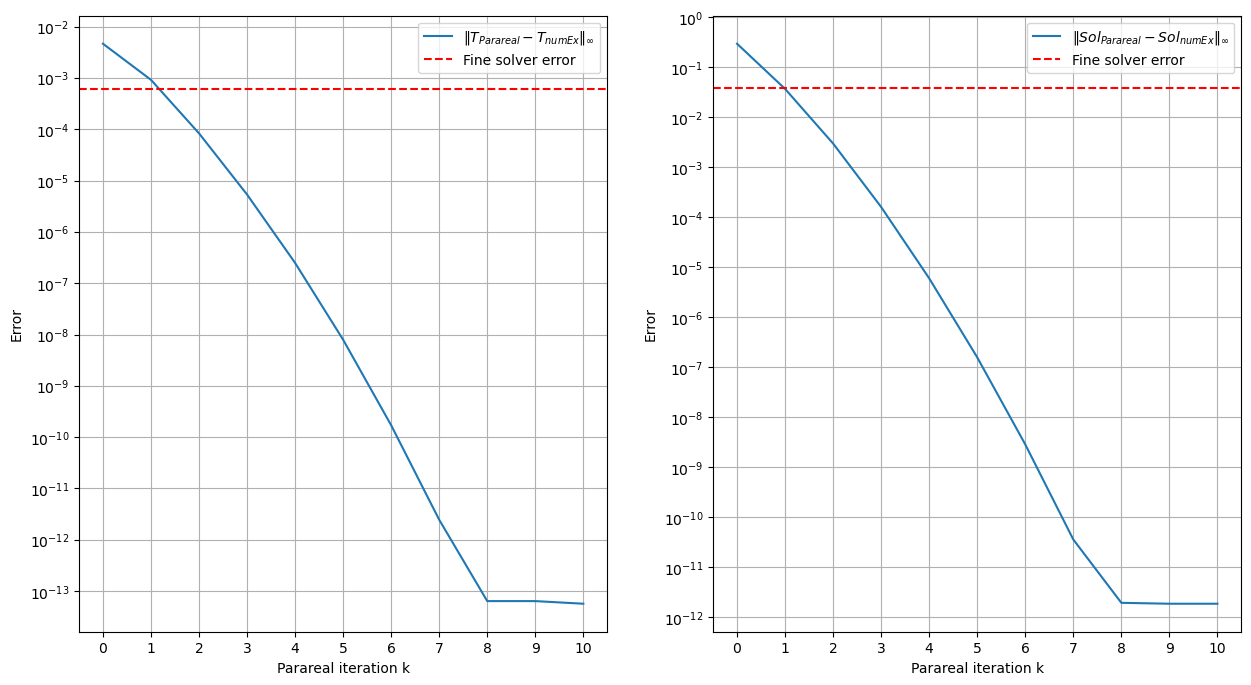

In [11]:
# compute L_inf error
dtF_index = np.where(dtVals == dtF)[0][0]        # find the index of dtF in dtVals
thres_TP = error_TP[dtF_index]                   # threshold for time error between analytical and fine numerical
thres_UP = error_UP[dtF_index]                   # threshold for solution error between analytical and fine numerical

error_TP_para = np.zeros(K+1)                    # time error between Parareal and fine numerical
error_UP_para = np.zeros(K+1)                    # solution error between Parareal and fine numerical

for k in range(K+1):
    error_TP_para[k] = np.linalg.norm(TP_Para[k,:]-TP_num[dtF_index,:],ord=np.inf)
    error_UP_para[k] = np.linalg.norm(UP_Para[k,:]-UP_num[dtF_index,:],ord=np.inf)
    
# plot
iterK = np.arange(K+1)
labelsT = [r'$\|T_{Parareal} - T_{numEx}\|_\infty$']
labelsSol = [r'$\|Sol_{Parareal} - Sol_{numEx}\|_\infty$']

fig = plt.figure(figsize=(15, 8))
plt.subplot(1,2, 1)
plt.semilogy(iterK, error_TP_para, label=labelsT)
plt.axhline(y=thres_TP, color='red', linestyle='--', label="Fine solver error")
plt.xticks(iterK)
plt.yscale('symlog', linthresh=1e-14)
plt.xlabel("Parareal iteration k"), plt.ylabel("Error"), plt.grid();
plt.legend()

plt.subplot(1,2, 2)
plt.semilogy(iterK, error_UP_para, label=labelsSol)
plt.xticks(iterK)
plt.yscale('symlog', linthresh=1e-14)
plt.axhline(y=thres_UP, color='red', linestyle='--', label="Fine solver error")
plt.xlabel("Parareal iteration k"), plt.ylabel("Error"), plt.grid();
plt.legend()
plt.show()

- Parareal error VS n-th pseudo-period for different iterations number

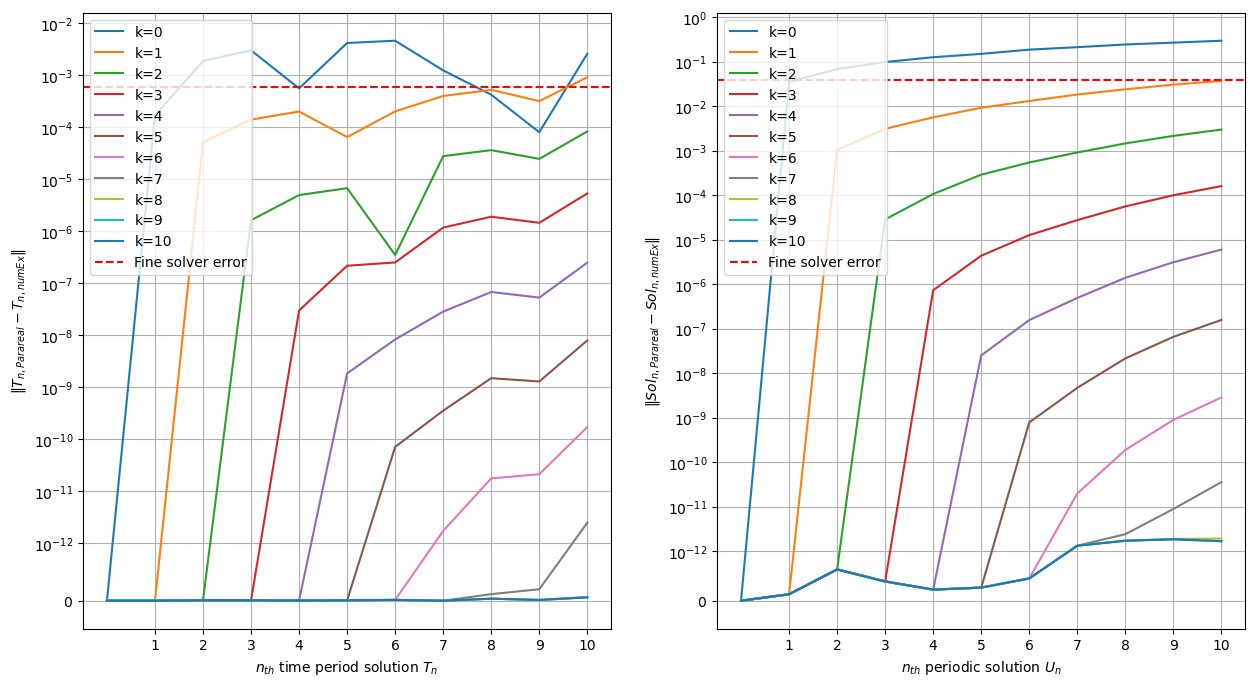

In [14]:
plt.figure(figsize=(15,8))
plt.subplot(1,2,1)
for k in range(K+1):
    err_T = np.abs(TP_Para[k,:]-TP_num[dtF_index,:])
    plt.semilogy(np.arange(N+1), err_T, label=f"k={k}")
plt.xticks(np.arange(1,N+1))
plt.axhline(y=thres_TP, color='red', linestyle='--', label="Fine solver error")
plt.yscale('symlog', linthresh=1e-12)
plt.xlabel("$n_{th}$ time period solution $T_n$"), plt.ylabel(r"$\|T_{n, Parareal} - T_{n,numEx}\|$")
plt.grid(True)
plt.legend(loc="upper left")


plt.subplot(1,2,2)
for k in range(K+1):
    err_U = np.abs(UP_Para[k,:]-UP_num[dtF_index,:])
    plt.semilogy(np.arange(N+1), err_U, label=f"k={k}")
plt.xticks(np.arange(1,N+1))
plt.axhline(y=thres_UP, color='red', linestyle='--', label="Fine solver error")
plt.yscale('symlog', linthresh=1e-12)
plt.xlabel("$n_{th}$ periodic solution $U_n$"), plt.ylabel(r'$\|Sol_{n,Parareal} - Sol_{n,numEx}\|$')
plt.grid(True)
plt.legend(loc="upper left")
plt.show()


The Parareal implementation with direct Backward-Euler solver without Newton.

In [17]:
check_func_BE = lambda u0,t0,nP:lambda t, u: check_event(t0, u0, t, u, alpha, lam(nP))
F2 = lambda u0, t0, nP: directSolverDahlquistEvent(f,df,y0=u0, t0=t0, dt=dtF, alpha=alpha, lam=lam(nP),event_func=check_func_BE(u0, t0, nP))[2:] # fine solver
G2 = lambda u0, t0, nP: directSolverDahlquistEvent(y0=u0, t0=t0, dt=dtG, alpha=alpha, lam=lam(nP),event_func=check_func_BE(u0, t0, nP))[2:] # coarse solver
TP_Para_2, UP_Para_2 = PararealModified(F2, G2, u0, t0, N, K)

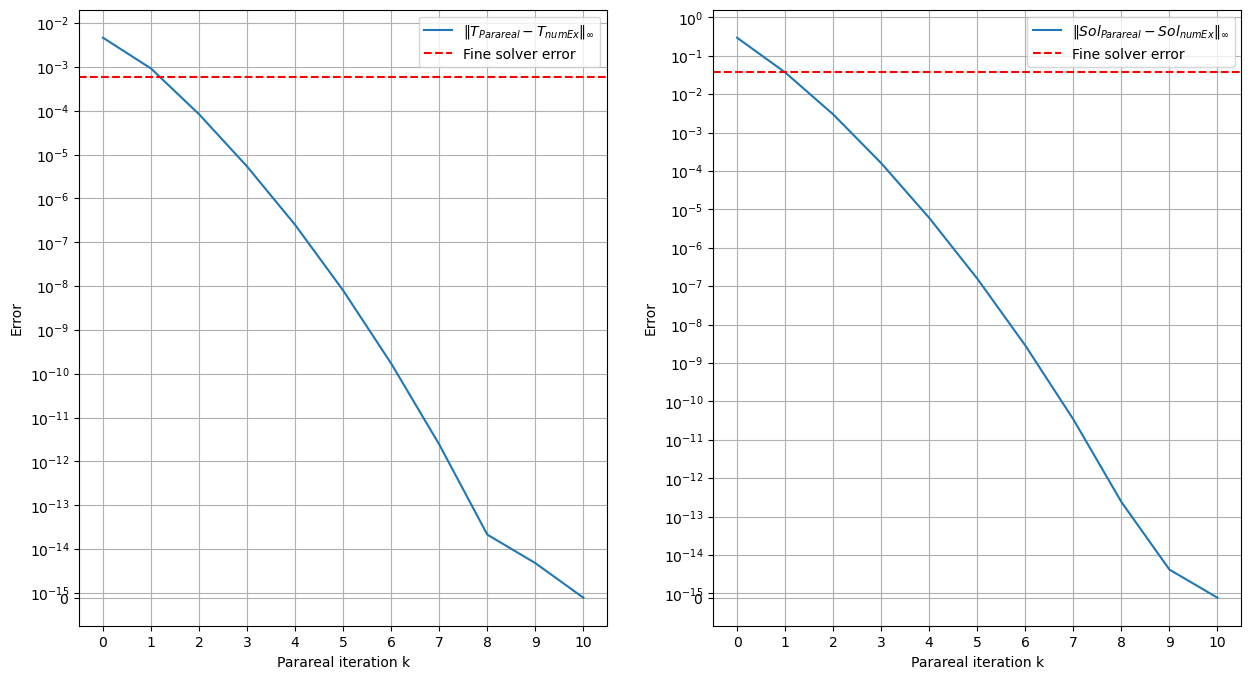

In [18]:
error_TP_para_2 = np.zeros(K+1)                    # time error between Parareal and fine numerical
error_UP_para_2 = np.zeros(K+1)                    # solution error between Parare

for k in range(K+1):
    error_TP_para_2[k] = np.linalg.norm(TP_Para_2[k,:]-TP_num[dtF_index,:],ord=np.inf)
    error_UP_para_2[k] = np.linalg.norm(UP_Para_2[k,:]-UP_num[dtF_index,:],ord=np.inf)

# plot
iterK = np.arange(K+1)
labelsT = [r'$\|T_{Parareal} - T_{numEx}\|_\infty$']
labelsSol = [r'$\|Sol_{Parareal} - Sol_{numEx}\|_\infty$']

fig = plt.figure(figsize=(15, 8))
plt.subplot(1,2, 1)
plt.semilogy(iterK, error_TP_para_2, label=labelsT)
plt.axhline(y=thres_TP, color='red', linestyle='--', label="Fine solver error")
plt.xticks(iterK)
plt.yscale('symlog', linthresh=1e-14)
plt.xlabel("Parareal iteration k"), plt.ylabel("Error"), plt.grid();
plt.legend()

plt.subplot(1,2, 2)
plt.semilogy(iterK, error_UP_para_2, label=labelsSol)
plt.xticks(iterK)
plt.yscale('symlog', linthresh=1e-14)
plt.axhline(y=thres_UP, color='red', linestyle='--', label="Fine solver error")
plt.xlabel("Parareal iteration k"), plt.ylabel("Error"), plt.grid();
plt.legend()
plt.show()

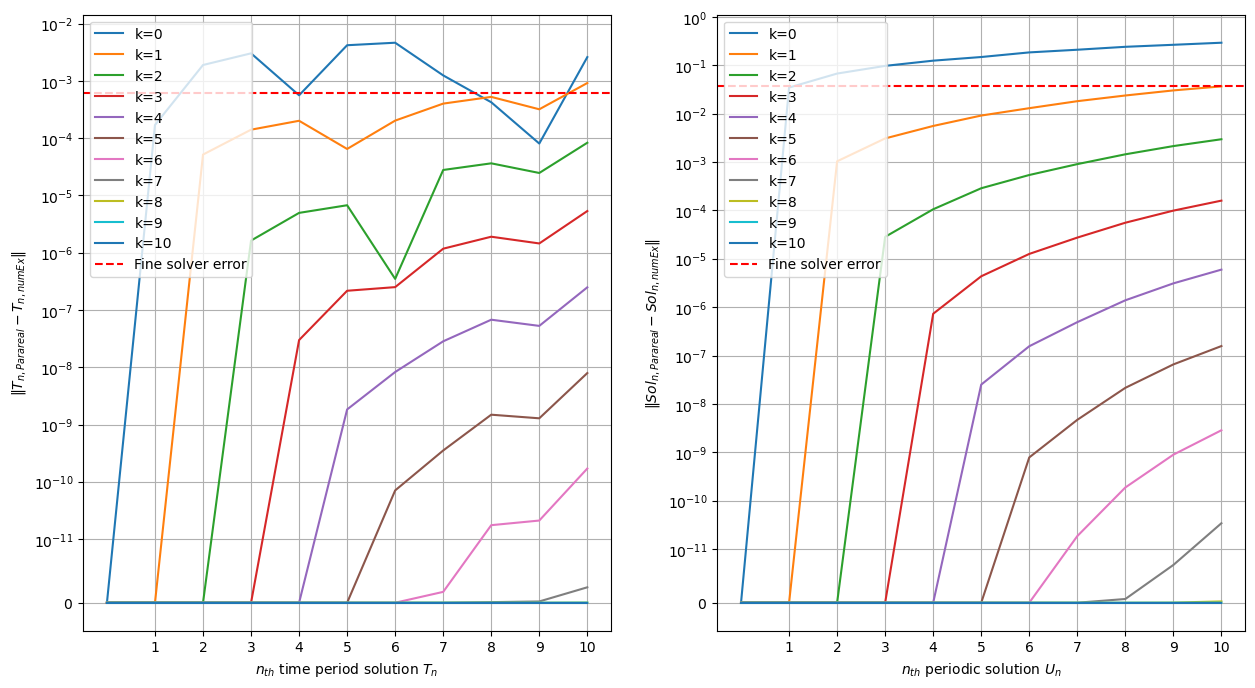

In [20]:
plt.figure(figsize=(15,8))
plt.subplot(1,2,1)
for k in range(K+1):
    err_T = np.abs(TP_Para_2[k,:]-TP_num[dtF_index,:])
    plt.semilogy(np.arange(N+1), err_T, label=f"k={k}")
plt.xticks(np.arange(1,N+1))
plt.axhline(y=thres_TP, color='red', linestyle='--', label="Fine solver error")
plt.yscale('symlog', linthresh=1e-11)
plt.xlabel("$n_{th}$ time period solution $T_n$"), plt.ylabel(r"$\|T_{n, Parareal} - T_{n,numEx}\|$")
plt.grid(True)
plt.legend(loc="upper left")


plt.subplot(1,2,2)
for k in range(K+1):
    err_U = np.abs(UP_Para_2[k,:]-UP_num[dtF_index,:])
    plt.semilogy(np.arange(N+1), err_U, label=f"k={k}")
plt.xticks(np.arange(1,N+1))
plt.axhline(y=thres_UP, color='red', linestyle='--', label="Fine solver error")
plt.yscale('symlog', linthresh=1e-11)
plt.xlabel("$n_{th}$ periodic solution $U_n$"), plt.ylabel(r'$\|Sol_{n,Parareal} - Sol_{n,numEx}\|$')
plt.grid(True)
plt.legend(loc="upper left")
plt.show()